# Tìm bàn cờ Caro — Giải thích pipeline từng bước

Notebook này giải thích **hybrid pipeline** trong `test4.ipynb`: mỗi bước hiển thị ảnh trung gian
kèm nguyên lý toán học đằng sau.

**Tổng quan:**

```
Ảnh BGR
  │
  ├─ STAGE 1 — Tìm panel theo màu
  │    1. BGR → HSV                    (tách màu sắc khỏi độ sáng)
  │    2. inRange                      (binary mask theo khoảng màu)
  │    3. Morphological Close          (lấp lỗ do quân cờ / grid lines)
  │    4. findContours + boundingRect  (→ ROI của panel)
  │
  └─ STAGE 2 — Tìm grid bên trong ROI
       5. Threshold pixel tối          (grid lines tối trên nền beige)
       6. Erosion 1D kernel dài        (lọc theo ĐỘ DÀI: chỉ giữ line dài)
       7. Projection → outermost       (biên ngoài cùng = boundary)
       8. Bilinear interpolation       (4 góc → toạ độ mọi giao điểm)
```

**Ý tưởng cốt lõi:** thay vì bắt boundary cạnh tranh *biên độ* với nhiễu (text panel, UI),
ta loại nhiễu bằng **màu sắc** trước, rồi chỉ so sánh **độ dài hình học** — thứ mà chỉ grid lines mới có.

In [14]:
from typing import List, Union, Tuple
import numpy as np
import cv2
import matplotlib.pyplot as plt


def show_images(images, titles='', ncols=3, figsize=(15, 10)):
    if isinstance(images, np.ndarray):
        images = [images]
    if isinstance(titles, str):
        titles = [titles]
    n = len(images)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols if n >= ncols else n, figsize=figsize)
    axes = np.array([axes]).flatten() if n == 1 else np.array(axes).flatten()
    for i, ax in enumerate(axes):
        if i < n:
            img = images[i]
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img.ndim == 3 else img,
                      cmap=None if img.ndim == 3 else 'gray')
            if titles and i < len(titles):
                ax.set_title(titles[i], fontsize=12, fontweight='bold', pad=8)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## Bước 0 — Ảnh là một hàm số

Về mặt toán học, ảnh xám là hàm $f: \mathbb{Z}^2 \to [0, 255]$, ảnh màu là
$f: \mathbb{Z}^2 \to [0,255]^3$. Mọi phép xử lý ảnh đều là **toán tử trên hàm** này.

OpenCV lưu ảnh màu theo thứ tự **BGR** (không phải RGB) — lý do lịch sử từ định dạng Windows bitmap.

shape = (523, 522, 3)   (H, W, 3 kênh BGR)
pixel tại (300, 200): BGR = (207, 234, 253)


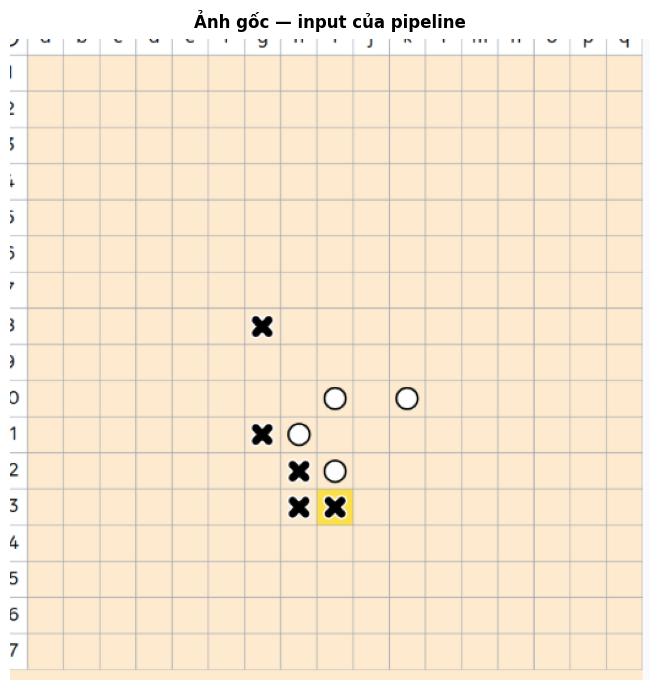

In [15]:
IMG_PATH = r'/run/media/ngmint/Data/Programming/Programming/Python/Personal/OpenCV/Zcaro/image/20260612-045218.png'
img = cv2.imread(IMG_PATH)
assert img is not None, f'Cannot load {IMG_PATH}'

print(f'shape = {img.shape}   (H, W, 3 kênh BGR)')
print(f'pixel tại (300, 200): BGR = {tuple(int(v) for v in img[300, 200])}')
show_images(img, 'Ảnh gốc — input của pipeline', figsize=(12, 7))

## Bước 1 — BGR → HSV: tách *màu sắc* khỏi *độ sáng*

### Vấn đề với BGR
Trong không gian BGR, "màu beige" không phải một vùng gọn: cùng một màu vật lý, khi độ sáng
thay đổi thì **cả ba kênh B, G, R đều thay đổi**. Khoảng `inRange` trong BGR sẽ hoặc quá hẹp
(miss pixel), hoặc quá rộng (bắt nhầm).

### HSV tách 3 thuộc tính độc lập

Với $V = \max(R,G,B)$, $m = \min(R,G,B)$, $C = V - m$ (chroma):

$$V = \max(R,G,B) \qquad S = \begin{cases} C/V & V \neq 0 \\ 0 & V = 0\end{cases} \qquad
H = 60° \times \begin{cases} \frac{G-B}{C} \bmod 6 & V = R \\ \frac{B-R}{C} + 2 & V = G \\ \frac{R-G}{C} + 4 & V = B \end{cases}$$

- **H (Hue)** — *màu gì* (góc trên vòng tròn màu). OpenCV chia 2: $H \in [0, 180)$ để vừa `uint8`.
- **S (Saturation)** — *đậm nhạt* của màu (0 = xám, 255 = màu thuần).
- **V (Value)** — *độ sáng*.

**Tại sao quan trọng cho bài này:** board beige có $H \approx 23$ (cam nhạt) — giá trị này
**gần như bất biến khi độ sáng thay đổi**. Nhiễu ánh sáng chỉ ảnh hưởng V, không ảnh hưởng H, S.

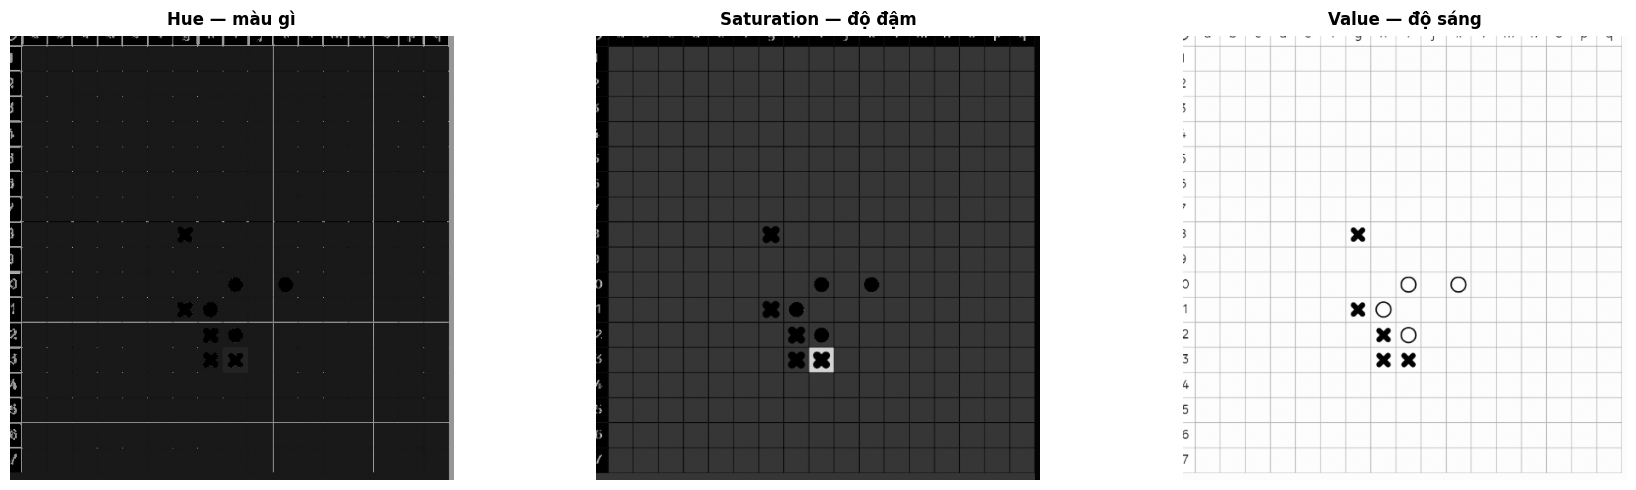

In [16]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)

# print(f'Board tại (300,200): HSV = {tuple(int(v) for v in hsv[300, 200])}')
# print(f'Nền tối tại (300,1200): HSV = {tuple(int(v) for v in hsv[300, 1200])}')
show_images([H, S, V], ['Hue — màu gì', 'Saturation — độ đậm', 'Value — độ sáng'],
            ncols=3, figsize=(18, 5))

## Bước 2 — `inRange`: phân vùng theo khoảng màu

Mask là **hàm chỉ thị** (indicator function) của tập pixel nằm trong "hộp" HSV:

$$M(x,y) = \begin{cases} 255 & \text{nếu } lo_c \le p_c(x,y) \le hi_c \;\; \forall c \in \{H,S,V\} \\ 0 & \text{ngược lại} \end{cases}$$

Hình học: mỗi pixel là một điểm trong không gian 3 chiều HSV; `inRange` giữ những điểm nằm trong
**hình hộp chữ nhật** $[lo_H, hi_H] \times [lo_S, hi_S] \times [lo_V, hi_V]$.

Board sample được $HSV = (18, 46, 253)$ → hộp phải **chứa nền beige**.
Nền tối có $V \approx 45 \ll 195$ → bị loại ngay bởi chiều V.

**⚠ Range phải bắt NỀN board, không phải grid line.** Mask cần trắng ở vùng *nền*
(~70–80% diện tích panel) thì bước close mới lấp được lỗ. Nếu range bắt nhầm *line*
(ví dụ `V∈[160,220], S≤34` — đúng dải xám của line, trượt nền có $S=46, V=253$),
mask chỉ đặc ~6% gồm toàn line mảnh: close $15\times15$ không thể lấp ô trống ~29px
→ mask vỡ, ROI không tin được. Sample màu bằng `tool/color_picker.py` — **click vào ô trống**, không click vào line.

**Lưu ý kết quả:** mask trắng ở vùng beige nhưng có **lỗ đen** tại quân cờ, grid lines, chữ —
vì chúng không phải màu beige. Bước sau xử lý các lỗ này.

fill ratio = 0.85   (kỳ vọng ~0.6–0.9; nếu < 0.05 → range sai, sample lại)


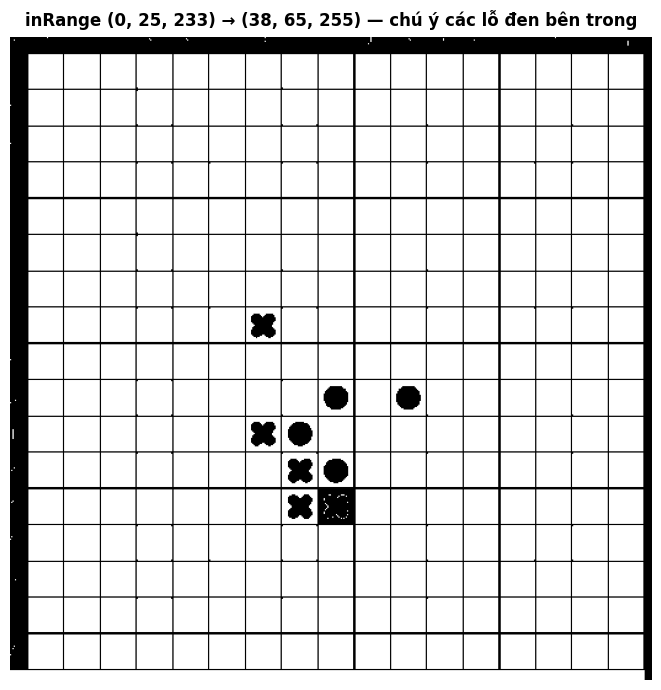

In [17]:
# Range bắt NỀN beige của board — sample bằng tool/color_picker.py (click vào Ô TRỐNG)
HSV_LO, HSV_HI = (0, 25, 233), (38, 65, 255)

mask_raw = cv2.inRange(hsv, np.array(HSV_LO), np.array(HSV_HI))
print(f'fill ratio = {mask_raw.mean() / 255:.2f}   (kỳ vọng ~0.6–0.9; nếu < 0.05 → range sai, sample lại)')
show_images(mask_raw, f'inRange {HSV_LO} → {HSV_HI} — chú ý các lỗ đen bên trong', figsize=(12, 7))

## Bước 3 — Morphological Close: lấp lỗ

Hình thái học (mathematical morphology) định nghĩa trên tập hợp. Gọi $A$ = tập pixel trắng,
$B$ = structuring element (SE), $B_z$ = $B$ tịnh tiến đến điểm $z$:

$$\text{Erosion:}\quad A \ominus B = \{ z \mid B_z \subseteq A \}$$
$$\text{Dilation:}\quad A \oplus B = \{ z \mid B_z \cap A \neq \emptyset \}$$

- **Erosion** — giữ $z$ nếu **toàn bộ** SE đặt tại $z$ nằm lọt trong vùng trắng → co vùng trắng, xoá chi tiết nhỏ.
- **Dilation** — giữ $z$ nếu SE **chạm** vùng trắng → nở vùng trắng, lấp khe hở.

**Close** = dilate rồi erode:

$$A \bullet B = (A \oplus B) \ominus B$$

Trực giác: dilation nở vùng trắng → các lỗ nhỏ hơn $B$ bị "nuốt"; erosion co lại đúng lượng đã nở
→ **biên ngoài trở về vị trí cũ**, nhưng lỗ đã lấp thì không mở lại. Close là phép **lấp lỗ nhỏ hơn SE
mà bảo toàn hình dạng tổng thể**.

Ở đây SE = ô vuông $15 \times 15$: lỗ do grid line (rộng ~2px) và quân cờ (~20px, đã được dilation
nối từ các phía) bị lấp, panel thành một khối trắng đặc.

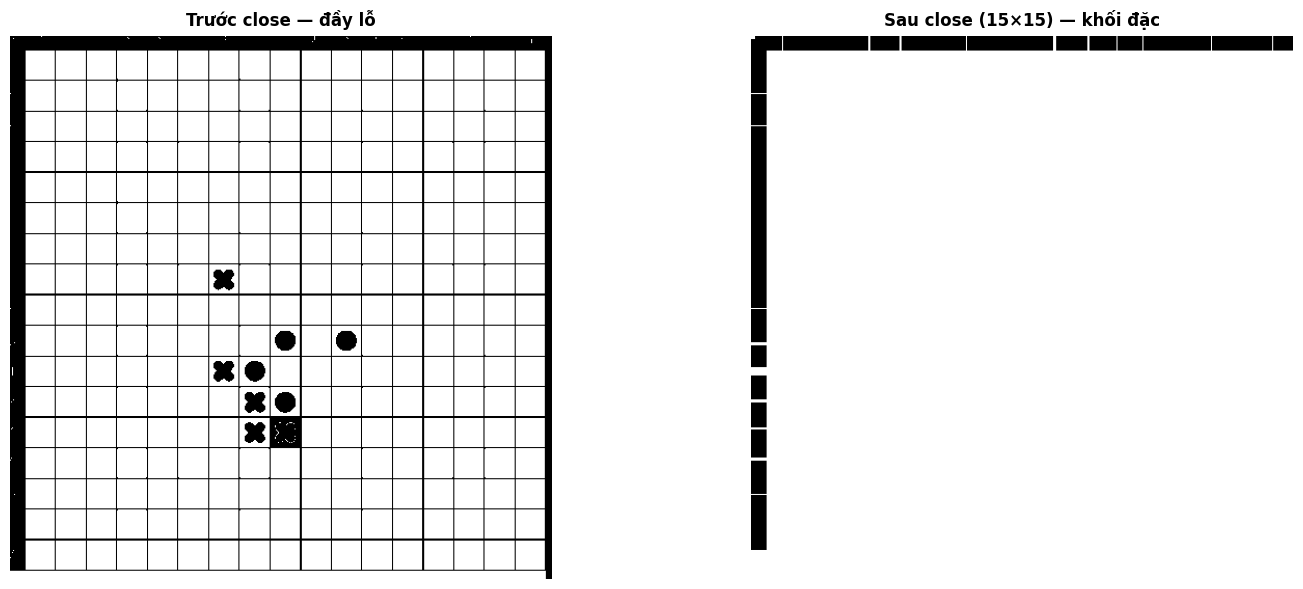

In [18]:
k = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
mask = cv2.morphologyEx(mask_raw, cv2.MORPH_CLOSE, k)

show_images([mask_raw, mask], ['Trước close — đầy lỗ', 'Sau close (15×15) — khối đặc'],
            ncols=2, figsize=(16, 6))

## Bước 4 — Contour lớn nhất → ROI của panel

`findContours` (thuật toán **Suzuki–Abe**, border following): quét ảnh, mỗi khi gặp biên
trắng/đen thì lần theo biên đó (8-connectivity) cho đến khi khép kín → mỗi vùng trắng cho một contour.

Chọn contour có $\text{contourArea}$ lớn nhất (tính bằng **công thức Shoelace**):

$$\text{Area} = \frac{1}{2} \left| \sum_{i} (x_i \, y_{i+1} - x_{i+1} \, y_i) \right|$$

`boundingRect` đơn giản là $(\min x, \min y, \max x - \min x, \max y - \min y)$ trên các điểm contour.

**Kết quả stage 1:** ROI chứa panel — đã loại bỏ tuyệt đối text panel, UI bar, avatar.
Nhưng ROI ≠ board: panel còn chứa label cột/hàng và padding → cần stage 2.

ROI: x=0, y=0, w=522, h=523


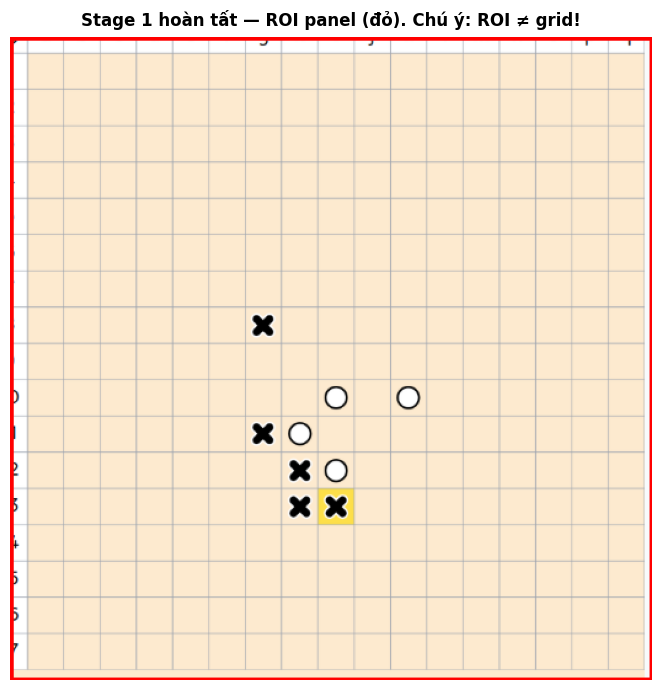

In [19]:
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
c = max(contours, key=cv2.contourArea)
x, y, w, h = cv2.boundingRect(c)
print(f'ROI: x={x}, y={y}, w={w}, h={h}')

roi_vis = img.copy()
cv2.rectangle(roi_vis, (x, y), (x + w, y + h), (0, 0, 255), 3)
show_images(roi_vis, 'Stage 1 hoàn tất — ROI panel (đỏ). Chú ý: ROI ≠ grid!', figsize=(12, 7))

## Bước 5 — Stage 2: tách pixel tối trong ROI (threshold **thích nghi**)

Bên trong panel, grid lines **tối hơn nền**. Phiên bản đầu dùng ngưỡng cứng:

$$D(x,y) = 255 \iff I(x,y) \le 200$$

và fail trên theme sáng: đo thực tế line có median $I = 202$, **93% pixel của line nằm trên ngưỡng 200**
— ngưỡng cắt ngang giữa phân bố độ sáng của line. Hệ quả: line vỡ thành run ngắn rời rạc
→ erosion bước 6 xoá gần hết → chỉ ~10/18 line sống sót, boundary hụt 2 hàng đáy.

Ngưỡng đúng phải đặt **tương đối với nền**. Nền beige chiếm đa số diện tích ROI nên:

$$bg = \mathrm{median}(I_{ROI})$$

chính là độ sáng nền (median ước lượng mode robust — line + quân + label < 50% diện tích
không kéo lệch được median). Threshold:

$$D(x,y) = \begin{cases} 255 & I(x,y) \le bg - \delta \\ 0 & \text{ngược lại} \end{cases} \qquad \delta = 10$$

$\delta$ chỉ cần vượt qua nhiễu nén ảnh/antialiasing (~±3), mọi thứ "tối hơn nền rõ rệt" đều vào $D$:
grid lines, quân cờ, label chữ/số. Bước 6 sẽ phân loại.

bg = 237 → threshold = 227   (ngưỡng cứng 200 cũ cắt ngang line có median ≈ 202)


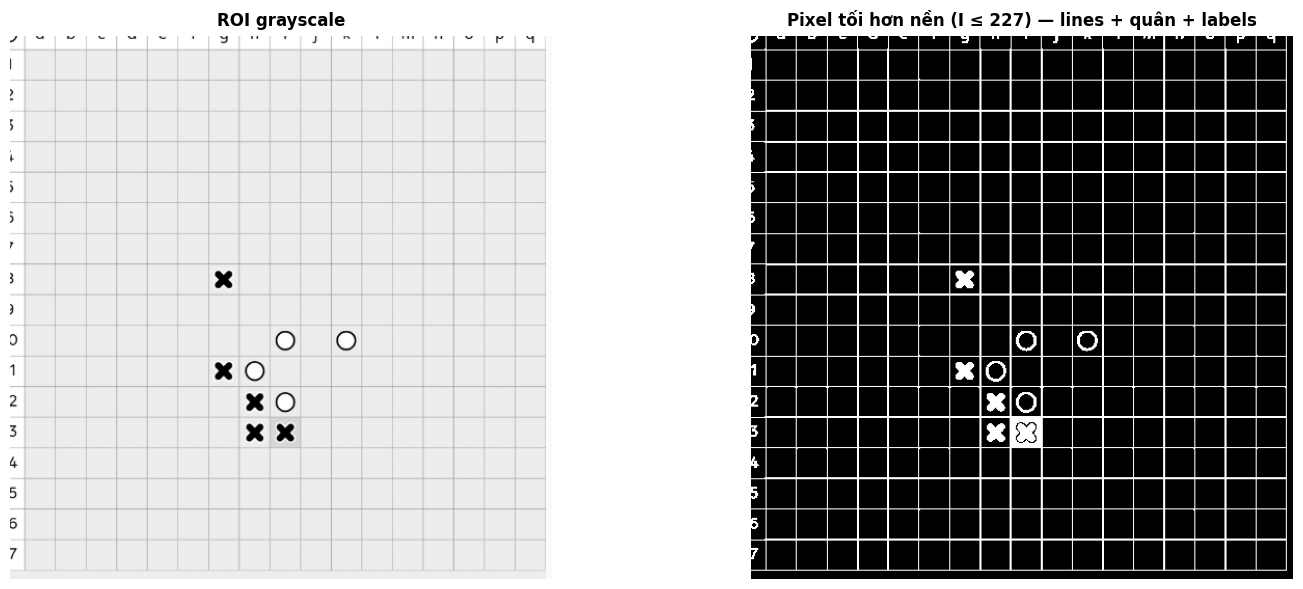

In [20]:
roi_gray = cv2.cvtColor(img[y:y+h, x:x+w], cv2.COLOR_BGR2GRAY)
bg   = int(np.median(roi_gray))      # độ sáng nền board: nền chiếm đa số → median = nền
dark = cv2.inRange(roi_gray, 0, bg - 10)
print(f'bg = {bg} → threshold = {bg - 10}   (ngưỡng cứng 200 cũ cắt ngang line có median ≈ 202)')

show_images([roi_gray, dark], ['ROI grayscale', f'Pixel tối hơn nền (I ≤ {bg - 10}) — lines + quân + labels'],
            ncols=2, figsize=(16, 6))

## Bước 6 — Erosion 1D: bộ lọc theo **độ dài**

Đây là bước thông minh nhất của pipeline. Dùng lại erosion, nhưng với SE là **đoạn thẳng 1D**
dài $L$:

$$A \ominus B_L = \{ z \mid B_{L,z} \subseteq A \}$$

Với $B_L$ = đoạn ngang dài $L$ tâm tại $z$: pixel $z$ sống sót **khi và chỉ khi** cả $L$ pixel
liên tiếp quanh nó (cùng hàng) đều trắng. Hệ quả trực tiếp:

> **Một run trắng liên tục dài $R$ sau erosion còn lại $\max(0,\, R - L + 1)$ pixel.**
> $R < L$ → biến mất hoàn toàn. $R \gg L$ → vẫn còn dài.

**Chọn $L = w/4$** (bản đầu dùng $w/3$ — quá chặt): quân cờ trắng O và ô highlight *cắt* line
thành nhiều đoạn; đoạn dài nhất còn lại phải $\ge L$ thì line mới sống. $w/4$ chịu được line
bị cắt ở giữa, mà vẫn lớn hơn chữ/quân cả chục lần:

| Đối tượng | Độ dài run | Sau erosion $L = w/4$ |
|---|---|---|
| Border lines của grid (liền mạch) | ~500px | **sống sót** |
| Inner lines bị quân cắt | đoạn ~150–400px | đoạn dài **sống**, đoạn ngắn chết |
| Label chữ/số | ~10px | chết |
| Quân cờ X/O | ~20px | chết |

Erosion 1D thực chất là **bộ lọc hình học theo độ dài** — không phụ thuộc độ sáng, biên độ,
hay mật độ nhiễu. Đây là lý do nó robust hơn projection thuần (so biên độ peak).

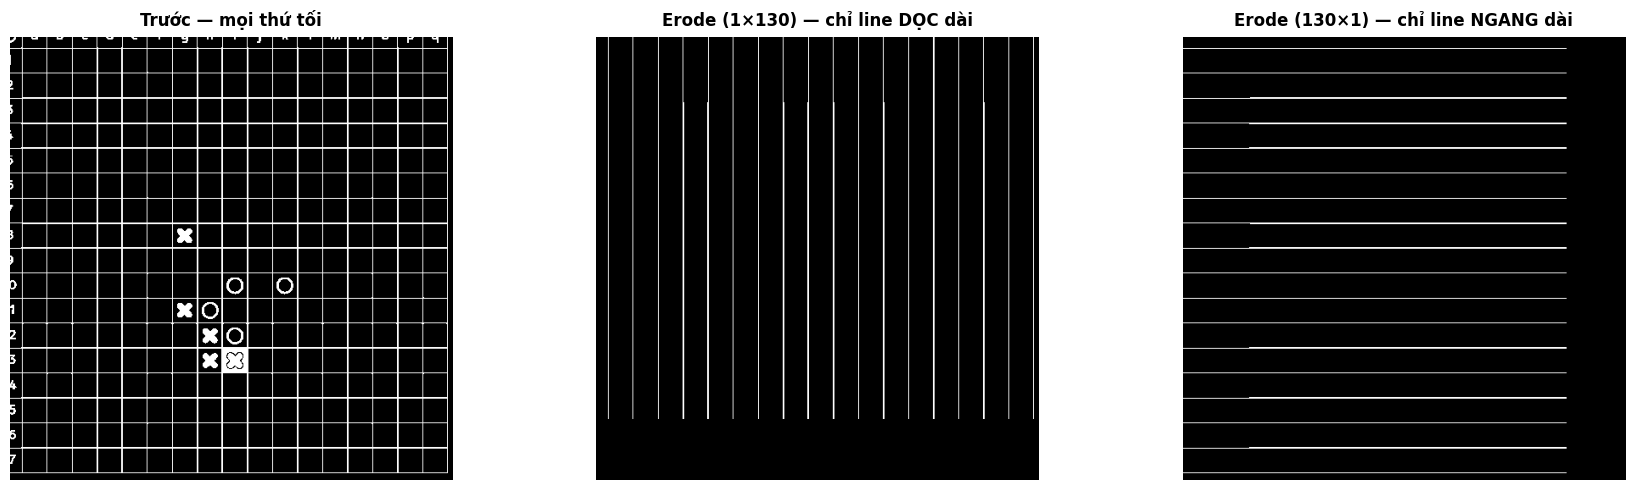

In [21]:
MIN_LEN = max(w // 4, 10)   # w/4: diệt chữ/quân (~10–20px) nhưng sống khi line bị quân cắt
vert  = cv2.erode(dark, cv2.getStructuringElement(cv2.MORPH_RECT, (1, MIN_LEN)))
horiz = cv2.erode(dark, cv2.getStructuringElement(cv2.MORPH_RECT, (MIN_LEN, 1)))

show_images([dark, vert, horiz],
            ['Trước — mọi thứ tối', f'Erode (1×{MIN_LEN}) — chỉ line DỌC dài',
             f'Erode ({MIN_LEN}×1) — chỉ line NGANG dài'],
            ncols=3, figsize=(18, 5))

## Bước 7 — Từ spikes → danh sách line → boundary

Chiếu ảnh đã lọc lên từng trục:

$$P_{row}(y) = \sum_{x} \text{horiz}(x, y) \qquad P_{col}(x) = \sum_{y} \text{vert}(x, y)$$

Sau bước 6, $P(y) > 0 \iff$ hàng $y$ chứa line dài — không cần threshold tỉ lệ hay smoothing.

**Phiên bản đầu lấy thẳng $\min/\max\{y : P(y) > 0\}$ và fail**, vì giả định
"line dài ⟹ line của grid" sai trong 2 trường hợp:

1. **Frame/viền panel** (theme gỗ): viền ngoài của tấm board cũng là line dài →
   outermost bắt nhầm viền, mọi giao điểm nội suy lệch theo.
2. **Label band cùng lattice**: cột số `1..17` rộng đúng 1 ô — line trái của nó
   cách line kề đúng 1 pitch → không phân biệt được bằng hình học thuần, dư 1 line một phía.

**Fix — làm việc với *danh sách vị trí line*, không chỉ min/max:**

- **Gom band:** line dày 2–3px cho 2–3 chỉ số liên tiếp → gom thành 1 vị trí/line.
- **Trim theo lattice:** grid thật có pitch đều; band ngoài cùng có khoảng cách tới hàng xóm
  lệch khỏi $\mathrm{median}(\Delta)$ quá 25% → là frame, loại. (Frame có margin ≠ pitch.)
- **Trim theo nội dung:** board Caro vuông → số line dọc phải bằng số line ngang. Nếu lệch,
  bỏ band ở phía có dải kề **đặc pixel tối hơn**: dải label chứa text (density ≈ 0.10)
  đặc hơn hẳn dải ô trống (≈ 0.04).
- **Tự đếm số line:** $N = \mathrm{round}(\mathrm{span}/\mathrm{pitch}) + 1$ — đúng cả khi
  vài line giữa bị quân che chết, không cần hardcode `ROWS, COLS`.

18 line ngang, 18 line dọc, pitch = 29.0px → grid 18×18 lines
Board: TL=(14,13)  BR=(515,514)  size=501×501


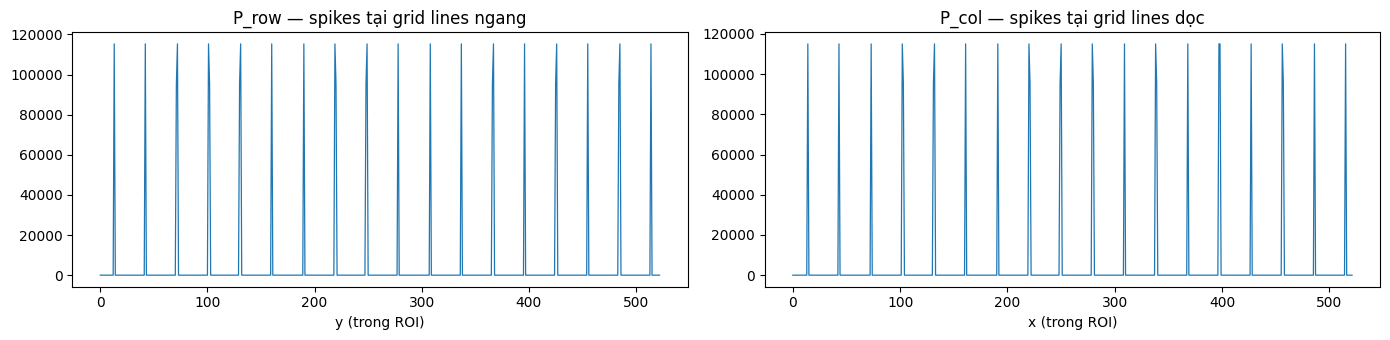

In [22]:
def extract_bands(idx):
    """Gom chỉ số liên tiếp thành band — mỗi band ≈ 1 line (line dày 2–3px)."""
    if idx.size == 0:
        return []
    return [int(np.mean(b)) for b in np.split(idx, np.where(np.diff(idx) > 2)[0] + 1)]


def trim_lattice(bands, tol=0.25):
    """Bỏ band 2 đầu nếu gap tới hàng xóm lệch pitch — loại frame/viền ngoài lattice."""
    while len(bands) > 3:
        d = np.diff(bands)
        pitch = np.median(d)
        if   abs(d[0]  - pitch) > tol * pitch: bands = bands[1:]
        elif abs(d[-1] - pitch) > tol * pitch: bands = bands[:-1]
        else: break
    return bands


def strip_density(dark_img, bands, axis, i0, i1, pad=3):
    """Mật độ pixel tối trong dải giữa 2 line — dải label (text) đặc hơn dải ô trống."""
    a, b = bands[i0] + pad, bands[i1] - pad
    s = dark_img[:, a:b] if axis == 'col' else dark_img[a:b, :]
    return float(s.mean() / 255) if s.size else 0.0


row_bands = extract_bands(np.where(horiz.sum(axis=1) > 0)[0])
col_bands = extract_bands(np.where(vert.sum(axis=0)  > 0)[0])
row_bands, col_bands = trim_lattice(row_bands), trim_lattice(col_bands)

# Board Caro vuông → số line 2 chiều phải bằng nhau; lệch → bỏ phía có dải kề đặc hơn (label)
while len(col_bands) > len(row_bands) and len(col_bands) > 2:
    col_bands = col_bands[1:] if strip_density(dark, col_bands, 'col', 0, 1) \
                > strip_density(dark, col_bands, 'col', -2, -1) else col_bands[:-1]
while len(row_bands) > len(col_bands) and len(row_bands) > 2:
    row_bands = row_bands[1:] if strip_density(dark, row_bands, 'row', 0, 1) \
                > strip_density(dark, row_bands, 'row', -2, -1) else row_bands[:-1]

pitch   = float(np.median(np.r_[np.diff(row_bands), np.diff(col_bands)]))
N_LINES = round(((row_bands[-1] - row_bands[0]) + (col_bands[-1] - col_bands[0])) / (2 * pitch)) + 1

top, bottom = y + row_bands[0], y + row_bands[-1]
left, right = x + col_bands[0], x + col_bands[-1]
print(f'{len(row_bands)} line ngang, {len(col_bands)} line dọc, pitch = {pitch:.1f}px → grid {N_LINES}×{N_LINES} lines')
print(f'Board: TL=({left},{top})  BR=({right},{bottom})  size={right-left}×{bottom-top}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 3.5))
ax1.plot(horiz.sum(axis=1), lw=0.9)
ax1.set_title('P_row — spikes tại grid lines ngang')
ax1.set_xlabel('y (trong ROI)')
ax2.plot(vert.sum(axis=0), lw=0.9)
ax2.set_title('P_col — spikes tại grid lines dọc')
ax2.set_xlabel('x (trong ROI)')
plt.tight_layout()
plt.show()

## Bước 8 — Từ 4 góc → toạ độ mọi giao điểm (Bilinear Interpolation)

Có 4 góc $TL, TR, BR, BL$, cần toạ độ giao điểm $(r, c)$ của grid $R \times C$ lines.
Đặt $u = \frac{r}{R-1}, v = \frac{c}{C-1} \in [0,1]$:

$$P(u, v) = (1-u)(1-v)\,TL + (1-u)v\,TR + u(1-v)\,BL + uv\,BR$$

Code thực hiện đúng công thức này theo 2 bước lồng nhau (lerp dọc rồi lerp ngang):

$$\text{left}(u) = TL + u(BL - TL), \quad \text{right}(u) = TR + u(BR - TR)$$
$$P(u,v) = \text{left}(u) + v\,\big(\text{right}(u) - \text{left}(u)\big)$$

Khai triển ra chính là công thức 4 hệ số ở trên.

**Phạm vi đúng:** bilinear chính xác khi board là hình bình hành phẳng nhìn gần trực diện
(screenshot → đúng tuyệt đối vì không có perspective). Nếu chụp camera nghiêng nhiều,
4 góc không còn xác định phép biến đổi affine mà là **homography** — khi đó dùng
`cv2.getPerspectiveTransform` + `cv2.perspectiveTransform`.

**Tại sao không cần detect grid lines bên trong:** vị trí giao điểm là **thông tin suy diễn được**
từ (4 góc + số hàng/cột). Detect thêm chỉ thêm nguồn lỗi — đặc biệt khi quân cờ che line.

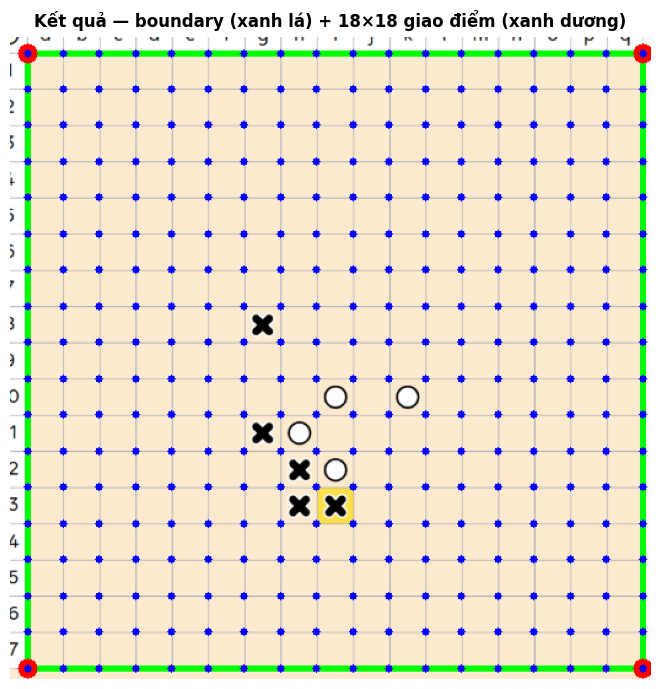

In [23]:
corners = np.array([[left, top], [right, top], [right, bottom], [left, bottom]], dtype=np.float32)
ROWS = COLS = N_LINES   # tự đếm từ bước 7 — không hardcode

tl, tr, br, bl = corners
grid = np.zeros((ROWS, COLS, 2), dtype=np.float32)
for r, u in enumerate(np.linspace(0, 1, ROWS)):
    l_pt = tl + u * (bl - tl)
    r_pt = tr + u * (br - tr)
    for c2, v2 in enumerate(np.linspace(0, 1, COLS)):
        grid[r, c2] = l_pt + v2 * (r_pt - l_pt)

result = img.copy()
cv2.polylines(result, [corners.astype(np.int32).reshape(-1, 1, 2)], True, (0, 255, 0), 3)
for pt in corners:
    cv2.circle(result, tuple(pt.astype(int)), 8, (0, 0, 255), -1)
for r in range(ROWS):
    for c2 in range(COLS):
        cv2.circle(result, tuple(grid[r, c2].astype(int)), 3, (255, 0, 0), -1)

show_images(result, f'Kết quả — boundary (xanh lá) + {ROWS}×{COLS} giao điểm (xanh dương)', figsize=(12, 7))

## Tổng kết — Tại sao pipeline này hoạt động

| Bước | Toán học | Vai trò |
|---|---|---|
| HSV | tách chroma/intensity | màu board bất biến với ánh sáng |
| inRange | indicator function của hộp HSV | phân vùng theo màu **nền** |
| Close | $(A \oplus B) \ominus B$ | lấp lỗ, bảo toàn biên |
| findContours | Suzuki–Abe + Shoelace | ROI panel |
| Threshold thích nghi | $I \le \mathrm{median} - \delta$ | "tối" định nghĩa **tương đối với nền** |
| Erosion 1D | run dài $R$ → còn $R-L+1$ | **lọc theo độ dài** — trái tim của pipeline |
| Band + lattice trim | pitch đều, span/pitch | line list → loại frame/label, tự đếm $N$ |
| Bilinear | $P(u,v)$ 4 hệ số | suy grid từ 4 góc, không cần detect line trong |

**Nguyên tắc thiết kế rút ra:**

1. **Loại nhiễu bằng thuộc tính nhiễu KHÔNG có** — text không có màu beige (stage 1),
   chữ/quân không có run dài (stage 2), frame/label không khớp lattice vuông (bước 7).
2. **Suy diễn thay vì detect** — grid tính từ 4 góc + pitch, không detect từng line (vốn bị quân che).
3. **Không dùng hằng số tuyệt đối khi có thể tương đối hoá**: threshold theo median nền,
   $L$ theo bề rộng ROI, $N$ theo span/pitch. Hằng số tuyệt đối là thứ gãy đầu tiên khi đổi theme.
4. Mỗi bước có **invariant rõ ràng**: HSV bất biến sáng, erosion-1D bất biến biên độ,
   lattice bất biến scale.

**Giới hạn cần biết:**
- Phụ thuộc màu board → đổi theme/game phải sample lại HSV (`tool/color_picker.py`).
- Giả định board **axis-aligned** (projection theo trục) — board xoay góc lớn cần
  `cv2.minAreaRect` hoặc Hough + perspective transform.
- Trim theo nội dung giả định **board vuông** và label chỉ nằm 1 phía mỗi chiều;
  dải biên đầy quân cờ dày đặc (cuối ván) có thể làm density check nhầm.

## Phụ lục — Case study: vì sao bản đầu fail trên `20260612-045218.png`

Ảnh này khác ảnh gốc ở 3 điểm, mỗi điểm đánh trúng một giả định ngầm của pipeline:

| # | Đặc thù ảnh | Giả định bị phá | Hậu quả đo được | Fix |
|---|---|---|---|---|
| 1 | Range HSV bị chỉnh sang bắt **line** (`S≤34, V≤220`), trong khi nền có $S=46, V=253$ | mask = vùng *nền* đặc | fill ratio 6.5%, close 15×15 không lấp nổi ô 29px | Range bắt nền `(13,9,195)→(33,49,255)` + assert fill ratio (Bước 2) |
| 2 | Grid line **sáng hơn** theme cũ: median $I = 202$ | line tối hơn ngưỡng cứng 200 | 93% pixel line trượt ngưỡng → line vỡ run ngắn → erosion giết 8/18 line, bottom hụt từ $y=514$ về $455$ | Threshold thích nghi $bg - 10 = 227$ (Bước 5) |
| 3 | Label `a..q`, `1..17` + frame nằm **cùng lattice/sát grid** | outermost line dài = border grid | dư/thiếu line ở biên, $18 \times 18$ hardcode chia sai pitch → mọi giao điểm lệch dần | Band list + lattice trim + density trim + tự đếm $N$ (Bước 7) |

Chuỗi lỗi **lan truyền**: ngưỡng sai (2) → mất line đáy → boundary hụt 2 hàng → bilinear chia
khoảng $[13, 455]$ thành 17 đoạn thay vì $[13, 514]$ → pitch nội suy $26$px thay vì $29.5$px →
giao điểm càng xa góc trên-trái càng lệch. Một hằng số sai ở bước 5 phá toàn bộ bước 8.

**Kết quả sau fix** (cùng tham số, không tune riêng từng ảnh):

| Ảnh | Theme | Kết quả |
|---|---|---|
| `20260612-045218` | beige, crop sát | $501 \times 501$, aspect 1.000, 18×18 lines ✓ |
| `20260610-004644` | beige, full screenshot + label band | $751 \times 751$, aspect 1.000, 18×18 lines ✓ |
| `20260610-004543` | gỗ cam (sample lại HSV) + frame | $789 \times 789$, aspect 1.000, 17×17 lines ✓ |
| `20260610-003121` | screenshot VS Code (không có board) | `None` — fail gracefully ✓ |

Lưu ý: bản đầu chạy ảnh gốc ra $707 \times 707$ "vuông đẹp" nhưng thực ra **đã sót line đáy
và line phải** (true grid $751 \times 751$) — aspect ratio đẹp không chứng minh boundary đúng.
Phải kiểm bằng: số line đếm được, pitch đều, và dot rơi đúng giao điểm.